# 3차시 딥러닝 1.Focus on image + sequence
#### 조대흠

---


## 1. 합성곱 신경망(CNN, Convolutional NN)

- 픽셀: 입력 이미지의 가장 기본적인 데이터 단위, 이미지의 각 저에서 밝기/색상을 나타내는 값

- 채널: 픽셀의 색을 숫자로 표현하는 방식 - gray scle, RGB, HSV

    - 그레이 스케일

        - 채널 값 = 1, 각픽셀은 0에서 값이 커질수록 하얀색이됨

        - 0~255 사이의 8비트 부호 없는 정수로 저장

    - RGB(컬러 이미지)

        - 채널 값 = 3, R,G,B 3가지 색의 명도를 뜻하는 숫자 3개가 합쳐진 벡터로 표현

        - 이미지 데이터는 3*세로 픽셀수 * 가로 픽셀수 형태의 3차원 배열로 저장
            

### 1-1 왜 이미지 처리에 MLP가 아닌 CNN을 사용할까?

- 이미지 데이터는 개별값을 H * W 행렬로 나타낼 수 있으며, 컬러의 경우 H*W*3 구조이다.
- 이미지는 픽셀 간의 공간적 관게가 중요한데, MLP는 픽셀을 일렬로 펼처 정리한다.

- 위치, 크기, 회전 등의 변화에 취약
    - 조금만 움직여도 입력값이 지속적으로 변함 -> 위치 변화에 따른 인식 성능 저하
    - CNN에서는 feature을 학습, pooling으로 차원 축소

- 파라미터 폭발
    - 각 픽셀에 대한 하나의 노드가 존재해야하므로 파라미터가 너무 많이 늘어남
    - 이에 가중치 수가 이미지 픽셀의 개수만큼 생성 - 과적합 가능성

    - CN에서는 부분 연결구조 & Convolution 연산으로 이미지의 특정 피쳐에만 집중

- 공간 정보 손실
    - 이미지를 1차원 벡터로 바로 변환하기 때문에 이미지의 공간 정보가 많이 소실

    - CNN에서는 다차원 이미지를 그대로 입력받고, 공간 정보를 보존하면서 학습

### 1-2 합성곱과 풀링

- 이미지 데이터는 공간적 관계와 지역적 패턴이 중요 - CNN사용

#### CNN 모델

- 위치 별 특징을 추출 + 클래스 분류하는 부분으로 구성
    - Feature learning: Convolution Layer + Pooling Layer
        - Convolution Layer: 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소
        - Pooling Layer: Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 특징 강조

    - Classification: CNN 모델의 마지막에 위치하고 Fully Connected Layer로 구성

    - Feature Learning와 Classification 사이에 3차원을 1차원 배열 형태로 만드는 Flatten 위치

     a. Convolution Layer
        - Filter 또는 Kernel이 이미지 위를 슬라이딩: filter 값은 MLP의 가중치와 같은 역할
        - 각 위치에서 요소별 곱셈 후 합계 계산
        - 결과를 Feature Map에 저장
            - feture map: input data에 filter을 적용하여 얻은 결과물
            - feature map의 차원은 filter의 수에 따라 결정
    
     b. Padding
        - filter을 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 것

     c. Stride
        - 이미지를 몇칸씩 점프하면서 훑을 것인지 결정하는 값
        - Stride = 1: 한 칸씩 이동(세밀한 특징 추출)
        - Stride = 2: 두 칸씩 이동(빠른 처리, 크기 축소)
        - Stride가 커질수록 featur map의 크기가 작아진다.

     d. Pooling
        - 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역안에서 가장 큰 값 또는 평균값을 취함
        - Max Pooling: 격자내의 최댓 값 선택
        - Average Pooling: 격자 내의 평균 값 선택

### 1-3 대표적인 CNN 아키텍처 살펴보기

- AlexNet
    - 머신러닝에서 벗어나 최초로 GPU를 이요해 학습한 대규모 CNN 모델 -> 5개의 Convolutional Layer + 3개의 Fully Connected Layers
    - ReLU 함수를 이용해 기울기 소실 문제 해소
    - Dropout을 통한 과적합 방지

- VGGNet
    - Conv + Pool을 여러번 반복
    - filter 크기가 3*3으로 고정
    - 단순하지만 층의 깊이를 늘려 정확도를 높임

- ResNet
    - 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결
    - 잔차연결: 이전 레이어


---

## 2. 이미지 딥러닝 응용

### 2-1 이미지 분류

- 아이디어: 이미지를 수치 데이터로 인식 -> 사전 정의된 클래스 중 하나로 분류

| 모델명 | 특징 요약 | 주의사항 |
| --- | --- | --- |
| **AlexNet** | 비교적 단순한 구조 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| **VGG** | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
| **ResNet** | Residual 연결로 매우 깊은 네트워크 가능 | 과적합 주의 |
| **Vision Transformer** | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |


### 2-2 객체 탐지

- 객체 검출은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업
- CNN을 통해 Feature Map을 얻고, 그 위에 두개의 head를 올림
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 좌표 예측


### 2-3 이미지 캡셔닝

- 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현

- 이미지 캡셔닝 단계
    - CNN을 이용한 특징 추출: RGB 3채널의 인풋 데이터를 ResNet-101을 이용하여 특징을 추출

- Attention Network를 이용하여 단어 생성
    - Attention Network를 통과하여 중요한 부분에 가중치를 두어 단어 추출
    - 가중치가 높은 부분을 이용해 사진을 한 문장으로 설명할 수 있게 함

- RNN을 이용하여 문장 완성
    - 가중치를 바탕으로 추출해낸 이미지의 주요 단어들을 RNN을 통해 조합하여 문장을 완성

---

## 3. 과거를 기억하는 신경망: RNN (Recurrent Neural Network)

### 3-1. 순차 데이터란?

- 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터: ex 음성, 자연어, 생물학적 서열, 비디오

- 기존 정형 데이터와의 차이점
    - 일반적인 정형 데이터: 샘플의 독립성, 특성 순서의 독립성 존재
    - 순차데이터는 요소의 순서 의존성과 자기상관성 존재

- 순차 데이터는 기존의 머신러닝 기법으로 한계가 있어, 과거의 정보를 기억하고 순서의 의미를 학습할 수 있는 특별한 신경망이 필요

### 3-2. RNN의 구조와 원리

#### RNN이란?
- 순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망
- 순환 신경망으로, 순환하는 은닉층이 매 시점의 은닉 상태를 업데이트 함
- 이전 시점의 값을 현재 시점으로 넘겨준다

#### RNN의 구조

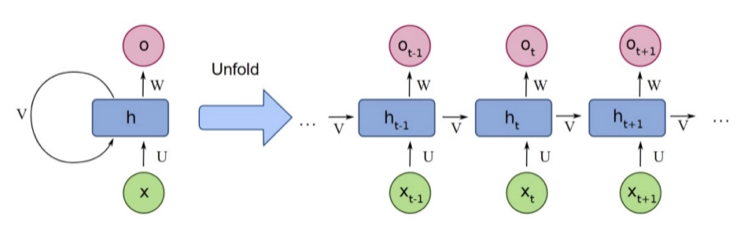

- 은닉 상태의 순환을 통해 과거의 정보를 지속적으로 다음 시점으로 전달하는 것


#### RNN의 핵심 원리: 가중치 공유
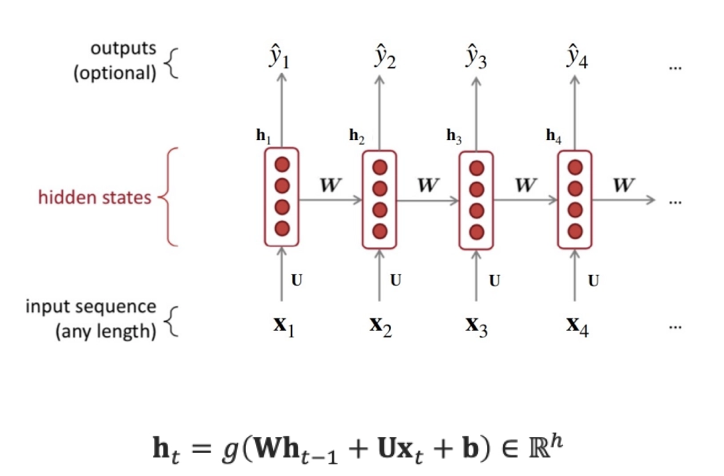
- 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
- RNN이 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 하는 원리.

- 이러한 가중치 공유를 통해 입력 시퀀스의 길이가 길어져도 학습해야 할 파라미터의 수가 일정하게 유지되어 학습 파라미터의 수 감소
- 이전 시점까지의 정보와 현재 시점의 입력이 주어졌을때, 정보를 어떻게 업데이트하는지에 대한 일반화 능력의 향상


### 3-3 RNN의 한계 및 장기 의존성 문제

#### RNN의 한계점
- 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐
    - 기울기 소실
        - 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못함
        - 역전파 과정에서 반복적으로 곱해지는 기울기의 크기가 1보다 작을때 0으로 수렵

    - 기울기 폭주
        - 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제
        - 역전파 과정에서 반복적으로 곱해지는 기울기의 크기가 1보다 클때 -> 기울기가 무한대로 발산

    - 느린 훈련 시간
        - 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계

    - 장기 의존성 문제
        - 시퀀스 앞부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상
        - 단기 기억력은 준수했지만, 장기 기억력에 문제 발생


---

## 4. LSTM & GRU


### 4-0 LSTM & GRU

#### LSTM

- 셀상태(장기기억): 절대 변하지 않는 핵심 기억
- 은닉상태(단기기억/출력): 현재 상황에서 바로 사용하는 기억. 셀 상태에서 필요한 정보만 꺼내, 지금 시점에서의 판단이나 출력으로 사용

- Forget Gate, Input Gate, Output Gate 존재

#### GRU

- 과거 기억과 새 정보의 비율 산정(Update Gate)

- 과거 기억을 얼마나 무시할지 정함 (Reset Gate)


### 4-1 게이트로 정보의 흐름을 제어하다: LSTM

#### LSTM

- 기억할 내용과 잊어버릴 내용을 선택해서, 중요한 정보들을 오래 가져감.
- c_t, h_t의 2개의 순환되는 층을 사용
- Gate를 통해 필요한 정보들만 통과
- Final memory cell에서 gate들의 결합을 통해 현재 정보를 얼마나 기억할지 계산

#### LSTM의 장,단점

- 장점: Gate를 통해 기억할 정보와 잊을 정보를 나누어, Vanishing gradient problem 해결
- 단점: RNN보다 학습 파라미터가 많아짐

### 4-2 더 단순하고 효율적인 구조: GRU

- LSTM에서 조금 더 발전한 것으로 별도의 메모리 셀 없이 게이트 수를 줄여 구조를 간소화
- Forget gate 와 input gate를 update gate하나로 합침.
- Reset gate 사용
- Gate 수가 3 -> 2로 줄어 학습 시간이 줄어듬
- but, 긴 시퀀스 처리에서의 한계는 여전히 존재


### 4-3 LSTM vs GRU: 언제 무엇을 선택할까?

#### LSTM vs GRU

| 구분 | LSTM | GRU |
| --- | --- | --- |
| **구조** | 3개 게이트 (입력, 삭제, 출력) | 2개 게이트 (업데이트, 리셋) |
| **복잡도** | 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음 |
| **학습 속도** | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| **메모리 사용량** | 큼 | 작음 |
| **장기 의존성 처리** | 더 강력 | LSTM과 비교해 다소 약함 |
| **연구/사례 축적** | 매우 많음 | 비교적 적음 |
| **성능** | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |

---

## 5. 문장을 입력받아 문장을 출력하다: Seq2Seq

### 5-0 Seq2Seq

- Encoder: 여러개의 정보를 하나로 압축 - context vector
- Decoder: context vector을 받아서 결과를 만듬

- 입력과 출력의 길이가 달라도 되며, 인코더와 디코더가 분리되어 있음
- context vector을 통해 Encoder -> Decoder

### 5-1 Seq2Seq의 기본 구조: 인코더와 디코더

- Seq2Seq
    - 한 시퀀스를 다른 시퀄스로 변환하는 작업을 수행하는 딥러닝 모델 - 기계번역에서 사용
    - 단어의 입력 개수와 출력 개수가 같지 않아도 됨
    - Encoder-Decoder 모델이라고도 불림

- Encoder & Decoder
    - Encoder
        - 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비: 여기서 압축된 정보는 context vector이라 부름

    - Decoder
        - 압축된 정보를 바탕으로 원하는 시퀀스 생성
        - Encoder가 보내준 context vector은 decoder의 첫번째 은닉 상태가 됨

    - Encoder, Decoder 모두 RNN을 여러개 조합한 형태
    - 모든 단어는 word2vec을 거침

### 5-2 Seq2Seq의 한계: 병목 현상

- 고정된 Context Vector에 소스 문장의 모든 정보를 압축하려 하니, 병목 현상 발생

---